In [21]:
import numpy as np
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

X = np.absolute(X)

X = np.round(X, 2) * 100

X = X.astype(int)

print(X)
print(y)

[[155 181]
 [ 45   7]
 [  2 128]
 [208 166]
 [ 48  25]
 [ 78  56]
 [217 131]
 [137 123]
 [132  86]
 [  5 149]
 [206  38]
 [ 54 117]
 [ 92 103]
 [229  19]
 [139  95]
 [  9 161]
 [ 66 150]
 [ 87 117]
 [109  61]
 [ 97 118]
 [143  36]
 [ 79 132]
 [ 82 130]
 [ 41  84]
 [141 263]
 [  6  43]
 [  7 168]
 [  8 158]
 [ 11  36]
 [ 63 163]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [22]:
import pandas as pd

y_new = y.reshape(len(y), 1)

data = np.concatenate((X, y_new), axis=1)

nama_kolom = ['Feature 1', 'Feature 2', 'Label']

df = pd.DataFrame(data, columns=nama_kolom)

df.head()

,Feature 1,Feature 2,Label
0,155,181,0
1,45,7,0
2,2,128,0
3,208,166,0
4,48,25,0


In [23]:
labels = {
    1 : 'Class A',
    0 : 'Class B'
}

df_label = df.copy()

df_label['Label'] = df_label['Label'].map(labels)

df_label.head()

,Feature 1,Feature 2,Label
0,155,181,Class B
1,45,7,Class B
2,2,128,Class B
3,208,166,Class B
4,48,25,Class B


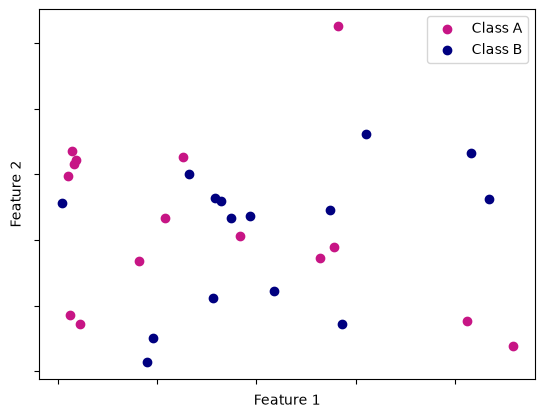

In [24]:
import matplotlib.pyplot as plt

colors = {
    'class_a': 'MediumVioletRed',
    'class_b': 'Navy'
}

gb = df_label.groupby(['Label'])
class_a = df_label[df_label['Label'] == 'Class A']
class_b = df_label[df_label['Label'] == 'Class B']

plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['class_a'])
plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['class_b'])
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(['Class A', 'Class B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mnb = MultinomialNB()

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

mnb.fit(X_train, y_train)

y_train_pred = mnb.predict(X_train)

acc_train = accuracy_score(y_train, y_train_pred)

y_test_pred = mnb.predict(X_test)

acc_test = accuracy_score(y_test, y_test_pred)

print(f'Training accuracy: {acc_train}')
print(f'Test accuracy: {acc_test}')

Training accuracy: 0.6190476190476191
Test accuracy: 0.7777777777777778


In [26]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_train_pred_gnb = gnb.predict(X_train)

acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

y_test_pred_gnb = gnb.predict(X_test)

acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

print(f'Training accuracy (Gaussian): {acc_train_gnb}')
print(f'Test accuracy (Gaussian): {acc_test_gnb}')

Training accuracy (Gaussian): 0.6190476190476191
Test accuracy (Gaussian): 0.3333333333333333
